In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import warnings
warnings.filterwarnings('ignore')
from sklearn.metrics import accuracy_score
import torchvision.models as models
from torchvision.models import resnet18
import os

In [3]:
# Создаем папку для сохранения изображений
os.makedirs('./images', exist_ok=True)
os.makedirs('./models', exist_ok=True)

# Устанавливаем seed для воспроизводимости
torch.manual_seed(42)
np.random.seed(42)

# Проверка доступности GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Используется устройство: {device}")

Используется устройство: cuda


In [4]:
class SinusoidalPositionEmbeddings(nn.Module):
    """
    Синусоидальные эмбеддинги для временных шагов
    """
    def __init__(self, dim):
        super().__init__()
        self.dim = dim

    def forward(self, time):
        device = time.device
        half_dim = self.dim // 2
        embeddings = np.log(10000) / (half_dim - 1)
        embeddings = torch.exp(torch.arange(half_dim, device=device) * -embeddings)
        embeddings = time[:, None] * embeddings[None, :]
        embeddings = torch.cat((embeddings.sin(), embeddings.cos()), dim=-1)
        return embeddings


class ResidualBlock(nn.Module):
    """
    Блок с остаточной связью для UNet
    """
    def __init__(self, in_channels, out_channels, time_emb_dim=None):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.SiLU(),
            nn.Linear(time_emb_dim, out_channels)
        ) if time_emb_dim else None

        self.conv1 = nn.Conv2d(in_channels, out_channels, 3, padding=1)
        self.bn1 = nn.BatchNorm2d(out_channels)
        self.conv2 = nn.Conv2d(out_channels, out_channels, 3, padding=1)
        self.bn2 = nn.BatchNorm2d(out_channels)
        self.relu = nn.ReLU()

        if in_channels != out_channels:
            self.skip = nn.Conv2d(in_channels, out_channels, 1)
        else:
            self.skip = nn.Identity()

    def forward(self, x, t_emb=None):
        identity = self.skip(x)

        out = self.conv1(x)
        out = self.bn1(out)
        out = self.relu(out)

        if self.time_mlp and t_emb is not None:
            out = out + self.time_mlp(t_emb)[:, :, None, None]

        out = self.conv2(out)
        out = self.bn2(out)
        out = self.relu(out)

        return out + identity


class UNet(nn.Module):
    """
    U-Net архитектура для изображений 28x28
    """
    def __init__(self, in_channels=1, out_channels=1, time_emb_dim=32):
        super().__init__()

        # Эмбеддинги времени
        self.time_emb = nn.Sequential(
            SinusoidalPositionEmbeddings(time_emb_dim),
            nn.Linear(time_emb_dim, time_emb_dim),
            nn.ReLU()
        )

        # Encoder
        self.enc1 = ResidualBlock(in_channels, 32, time_emb_dim)
        self.enc2 = ResidualBlock(32, 64, time_emb_dim)
        self.enc3 = ResidualBlock(64, 128, time_emb_dim)

        # Пулы
        self.pool = nn.MaxPool2d(2)

        # Bottleneck
        self.bottleneck = ResidualBlock(128, 256, time_emb_dim)

        # Decoder
        self.up3 = nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1)
        self.dec3 = ResidualBlock(256, 128, time_emb_dim)
        
        self.up2 = nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1)
        self.dec2 = ResidualBlock(128, 64, time_emb_dim)
        
        self.up1 = nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1)
        self.dec1 = ResidualBlock(64, 32, time_emb_dim)

        # Выходной слой
        self.final = nn.Conv2d(32, out_channels, 1)
        
        # Адаптивный пул для обеспечения правильного размера
        self.adaptive_pool = nn.AdaptiveAvgPool2d((28, 28))

    def get_encoder_output_size(self, x):
        """Вычисляет размер после энкодера"""
        h = self.pool(self.enc1(x, None))
        h = self.pool(self.enc2(h, None))
        h = self.pool(self.enc3(h, None))
        return h.shape[2:]

    def forward(self, x, t):
        # Эмбеддинг времени
        t_emb = self.time_emb(t)

        # Encoder с сохранением размеров для skip connections
        e1 = self.enc1(x, t_emb)
        e2 = self.enc2(self.pool(e1), t_emb)
        e3 = self.enc3(self.pool(e2), t_emb)

        # Bottleneck
        b = self.bottleneck(self.pool(e3), t_emb)

        # Decoder со skip connections
        d3 = self.up3(b)
        
        # Проверяем и при необходимости адаптируем размеры для конкатенации
        if d3.shape[2:] != e3.shape[2:]:
            d3 = F.interpolate(d3, size=e3.shape[2:], mode='bilinear', align_corners=False)
        
        d3 = torch.cat([d3, e3], dim=1)
        d3 = self.dec3(d3, t_emb)

        d2 = self.up2(d3)
        if d2.shape[2:] != e2.shape[2:]:
            d2 = F.interpolate(d2, size=e2.shape[2:], mode='bilinear', align_corners=False)
        
        d2 = torch.cat([d2, e2], dim=1)
        d2 = self.dec2(d2, t_emb)

        d1 = self.up1(d2)
        if d1.shape[2:] != e1.shape[2:]:
            d1 = F.interpolate(d1, size=e1.shape[2:], mode='bilinear', align_corners=False)
        
        d1 = torch.cat([d1, e1], dim=1)
        d1 = self.dec1(d1, t_emb)

        # Выходной слой и адаптивный пул до нужного размера
        out = self.final(d1)
        out = self.adaptive_pool(out)
        
        return out


class DDPM:
    """
    Denoising Diffusion Probabilistic Model
    """
    def __init__(self, model, n_steps=500, beta_start=1e-4, beta_end=0.02, device='cpu'):
        self.model = model.to(device)
        self.n_steps = n_steps
        self.device = device

        # Планирование шума (линейное)
        self.betas = torch.linspace(beta_start, beta_end, n_steps).to(device)
        self.alphas = 1 - self.betas
        self.alpha_bars = torch.cumprod(self.alphas, dim=0)

    def add_noise(self, x_0, t):
        """
        Добавление шума к изображению на шаге t
        """
        alpha_bar = self.alpha_bars[t][:, None, None, None]
        epsilon = torch.randn_like(x_0)
        x_t = torch.sqrt(alpha_bar) * x_0 + torch.sqrt(1 - alpha_bar) * epsilon
        return x_t, epsilon

    def train_step(self, x_0, optimizer):
        """
        Один шаг обучения
        """
        self.model.train()
        batch_size = x_0.shape[0]

        # Случайный шаг времени
        t = torch.randint(0, self.n_steps, (batch_size,), device=self.device)

        # Добавляем шум
        x_t, epsilon = self.add_noise(x_0, t)

        # Предсказываем шум
        epsilon_pred = self.model(x_t, t)

        # MSE loss
        loss = F.mse_loss(epsilon_pred, epsilon)

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()

        return loss.item()

    @torch.no_grad()
    def sample(self, n_samples=64, return_all=False):
        """
        Генерация изображений
        """
        self.model.eval()

        # Начинаем с чистого шума
        x = torch.randn(n_samples, 1, 28, 28).to(self.device)

        if return_all:
            images = [x.cpu().numpy()]

        # Обратный процесс
        for t in reversed(range(self.n_steps)):
            t_batch = torch.full((n_samples,), t, device=self.device, dtype=torch.long)

            # Предсказываем шум
            epsilon_pred = self.model(x, t_batch)

            # Обновляем x
            alpha = self.alphas[t]
            alpha_bar = self.alpha_bars[t]
            beta = self.betas[t]

            if t > 0:
                noise = torch.randn_like(x)
            else:
                noise = 0

            x = 1 / torch.sqrt(alpha) * (x - ((1 - alpha) / torch.sqrt(1 - alpha_bar)) * epsilon_pred) + torch.sqrt(beta) * noise

            if return_all and t % (self.n_steps // 10) == 0:
                images.append(x.cpu().numpy())

        if return_all:
            return np.array(images)
        else:
            return (x.cpu().numpy() + 1) / 2  # Денормализация

In [5]:
def load_data(batch_size=128, dataset='mnist'):
    """
    Загрузка датасета MNIST или Fashion-MNIST
    """
    transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize((0.5,), (0.5,))  # Нормализация к [-1, 1]
    ])

    if dataset.lower() == 'mnist':
        train_dataset = datasets.MNIST(root='./data', train=True, download=True, transform=transform)
        test_dataset = datasets.MNIST(root='./data', train=False, download=True, transform=transform)
    else:
        train_dataset = datasets.FashionMNIST(root='./data', train=True, download=True, transform=transform)
        test_dataset = datasets.FashionMNIST(root='./data', train=False, download=True, transform=transform)

    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False)

    return train_loader, test_loader

# Загрузка данных
train_loader, test_loader = load_data(batch_size=128, dataset='mnist')
print(f"Размер обучающей выборки: {len(train_loader.dataset)}")
print(f"Размер тестовой выборки: {len(test_loader.dataset)}")

Размер обучающей выборки: 60000
Размер тестовой выборки: 10000


In [6]:
class VAE(nn.Module):
    """
    Вариационный автоэнкодер для изображений 28x28
    """
    def __init__(self, latent_dim=20):
        super(VAE, self).__init__()
        self.latent_dim = latent_dim

        # Encoder
        self.encoder = nn.Sequential(
            nn.Conv2d(1, 32, kernel_size=3, stride=2, padding=1),  # 14x14
            nn.ReLU(),
            nn.Conv2d(32, 64, kernel_size=3, stride=2, padding=1),  # 7x7
            nn.ReLU(),
            nn.Conv2d(64, 128, kernel_size=3, stride=2, padding=1),  # 4x4
            nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 4 * 4, 256),
            nn.ReLU()
        )

        # Выходы для среднего и логарифма дисперсии
        self.fc_mu = nn.Linear(256, latent_dim)
        self.fc_logvar = nn.Linear(256, latent_dim)

        # Decoder
        self.decoder_input = nn.Linear(latent_dim, 256)
        self.decoder = nn.Sequential(
            nn.Linear(256, 128 * 4 * 4),
            nn.ReLU(),
            nn.Unflatten(1, (128, 4, 4)),
            nn.ConvTranspose2d(128, 64, kernel_size=4, stride=2, padding=1),  # 8x8
            nn.ReLU(),
            nn.ConvTranspose2d(64, 32, kernel_size=4, stride=2, padding=1),   # 16x16
            nn.ReLU(),
            nn.ConvTranspose2d(32, 1, kernel_size=4, stride=2, padding=1),     # 32x32
            nn.Conv2d(1, 1, kernel_size=3, stride=1, padding=1)  # Дополнительный слой для сглаживания
        )

    def encode(self, x):
        h = self.encoder(x)
        mu = self.fc_mu(h)
        logvar = self.fc_logvar(h)
        return mu, logvar

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def decode(self, z):
        h = self.decoder_input(z)
        x_recon = self.decoder(h)
        # Обрезаем до 28x28 (исходный размер)
        x_recon = x_recon[:, :, 2:30, 2:30]
        return torch.tanh(x_recon) 

    def forward(self, x):
        mu, logvar = self.encode(x)
        z = self.reparameterize(mu, logvar)
        recon_x = self.decode(z)
        return recon_x, mu, logvar

def vae_loss(recon_x, x, mu, logvar, beta=1.0):
    """
    VAE loss: реконструкция + KL-дивергенция
    """
    recon_loss = F.mse_loss(recon_x, x, reduction='sum')
    kl_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
    return recon_loss + beta * kl_loss, recon_loss, kl_loss

def train_vae(model, train_loader, epochs=15, lr=1e-3, beta=1.0, device='cpu'):
    """
    Обучение VAE
    """
    optimizer = optim.Adam(model.parameters(), lr=lr)
    model.train()

    train_losses = []
    recon_losses = []
    kl_losses = []

    for epoch in range(epochs):
        total_loss = 0
        total_recon = 0
        total_kl = 0
        num_batches = 0

        progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{epochs}')
        for batch_idx, (data, _) in enumerate(progress_bar):
            data = data.to(device)

            optimizer.zero_grad()
            recon_batch, mu, logvar = model(data)
            loss, recon, kl = vae_loss(recon_batch, data, mu, logvar, beta)

            loss.backward()
            optimizer.step()

            total_loss += loss.item()
            total_recon += recon.item()
            total_kl += kl.item()
            num_batches += 1

            progress_bar.set_postfix({
                'loss': loss.item() / len(data),
                'recon': recon.item() / len(data),
                'kl': kl.item() / len(data)
            })

        avg_loss = total_loss / (num_batches * train_loader.batch_size)
        avg_recon = total_recon / (num_batches * train_loader.batch_size)
        avg_kl = total_kl / (num_batches * train_loader.batch_size)

        train_losses.append(avg_loss)
        recon_losses.append(avg_recon)
        kl_losses.append(avg_kl)

        print(f'Epoch {epoch+1}: Average Loss = {avg_loss:.4f}, '
              f'Recon = {avg_recon:.4f}, KL = {avg_kl:.4f}')

    return train_losses, recon_losses, kl_losses

In [7]:
# Обучаем VAE
print("Обучение VAE")

vae_model = VAE(latent_dim=20).to(device)
print(f"Количество параметров VAE: {sum(p.numel() for p in vae_model.parameters()):,}")

vae_train_losses, vae_recon_losses, vae_kl_losses = train_vae(
    vae_model, train_loader, epochs=15, lr=1e-3, beta=1.0, device=device
)

# Сохраняем VAE
torch.save(vae_model.state_dict(), './models/vae_mnist.pth')

Обучение VAE
Количество параметров VAE: 1,323,667


Epoch 1/15: 100%|██████████| 469/469 [00:03<00:00, 153.21it/s, loss=92.2, recon=74, kl=18.1]  


Epoch 1: Average Loss = 152.2109, Recon = 140.6292, KL = 11.5817


Epoch 2/15: 100%|██████████| 469/469 [00:02<00:00, 180.45it/s, loss=68.2, recon=47.5, kl=20.8]


Epoch 2: Average Loss = 82.1737, Recon = 62.7237, KL = 19.4500


...

Epoch 13: Average Loss = 57.6185, Recon = 34.6472, KL = 22.9713


Epoch 14/15: 100%|██████████| 469/469 [00:02<00:00, 193.28it/s, loss=61.5, recon=38, kl=23.4]  


Epoch 14: Average Loss = 57.4341, Recon = 34.4797, KL = 22.9544


Epoch 15/15: 100%|██████████| 469/469 [00:02<00:00, 190.02it/s, loss=59.4, recon=35.9, kl=23.5]


Epoch 15: Average Loss = 57.1115, Recon = 34.1605, KL = 22.9510


In [8]:
# Обучаем диффузионную модель
print("Обучение диффузионной модели")

unet = UNet(in_channels=1, out_channels=1, time_emb_dim=32)
ddpm = DDPM(unet, n_steps=500, beta_start=1e-4, beta_end=0.02, device=device)
print(f"Количество параметров DDPM: {sum(p.numel() for p in unet.parameters()):,}")

optimizer = optim.Adam(unet.parameters(), lr=2e-4)
n_epochs = 10
ddpm_losses = []

for epoch in range(n_epochs):
    epoch_loss = 0
    num_batches = 0

    progress_bar = tqdm(train_loader, desc=f'Epoch {epoch+1}/{n_epochs}')
    for batch_idx, (data, _) in enumerate(progress_bar):
        data = data.to(device)
        loss = ddpm.train_step(data, optimizer)

        epoch_loss += loss
        num_batches += 1

        progress_bar.set_postfix({'loss': loss})

    avg_loss = epoch_loss / num_batches
    ddpm_losses.append(avg_loss)
    print(f'Epoch {epoch+1}: Average Loss = {avg_loss:.4f}')

# Сохраняем DDPM
torch.save(unet.state_dict(), './models/ddpm_mnist.pth')

Обучение диффузионной модели
Количество параметров DDPM: 2,554,977


Epoch 1/10: 100%|██████████| 469/469 [00:08<00:00, 57.27it/s, loss=0.0571]


Epoch 1: Average Loss = 0.1068


Epoch 2/10: 100%|██████████| 469/469 [00:07<00:00, 59.76it/s, loss=0.0502]


Epoch 2: Average Loss = 0.0628


...

Epoch 8: Average Loss = 0.0415


Epoch 9/10: 100%|██████████| 469/469 [00:07<00:00, 60.30it/s, loss=0.0419]


Epoch 9: Average Loss = 0.0397


Epoch 10/10: 100%|██████████| 469/469 [00:07<00:00, 60.11it/s, loss=0.0441]


Epoch 10: Average Loss = 0.0396


Генерация изображений
Сгенерировано 200 изображений VAE
Сгенерировано 200 изображений DDPM


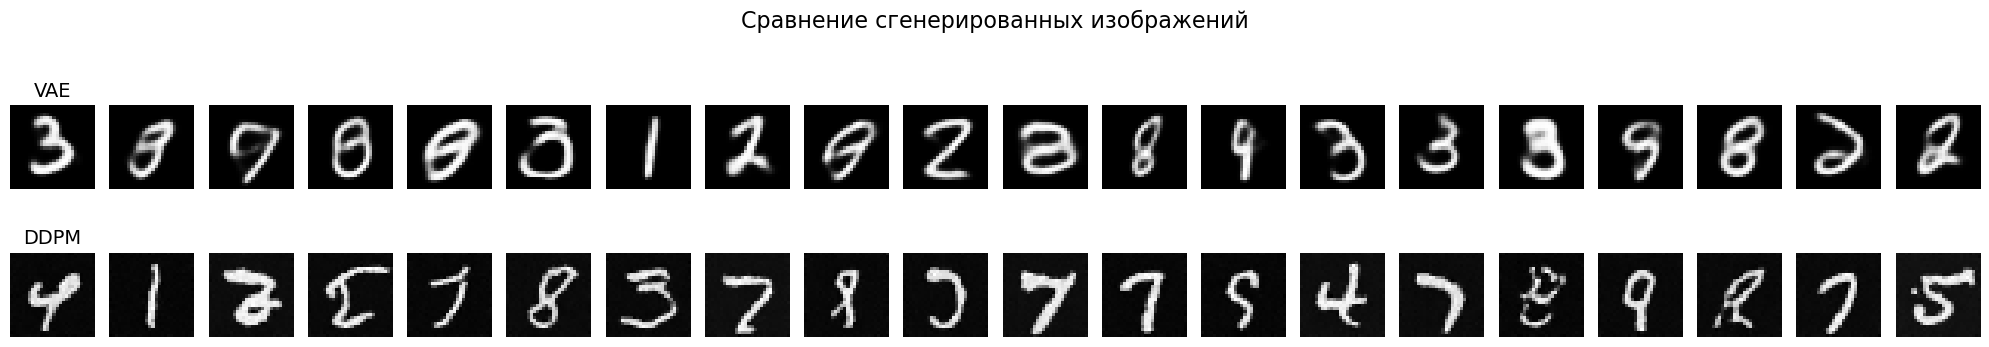

In [9]:
print("Генерация изображений")

# Генерация VAE
def generate_vae_samples(model, num_samples=200, device='cpu'):
    model.eval()
    with torch.no_grad():
        z = torch.randn(num_samples, model.latent_dim).to(device)
        samples = model.decode(z)
        samples = (samples.cpu().numpy() + 1) / 2  # Денормализация к [0, 1]
    return samples

vae_samples = generate_vae_samples(vae_model, num_samples=200, device=device)
print(f"Сгенерировано {len(vae_samples)} изображений VAE")

# Генерация DDPM
ddpm_samples = ddpm.sample(n_samples=200)
print(f"Сгенерировано {len(ddpm_samples)} изображений DDPM")

# Визуализация примеров
def plot_comparison_grid(vae_samples, ddpm_samples, n_samples=20):
    fig, axes = plt.subplots(2, n_samples, figsize=(20, 4))

    for i in range(n_samples):
        axes[0, i].imshow(vae_samples[i].squeeze(), cmap='gray')
        axes[0, i].axis('off')
        if i == 0:
            axes[0, i].set_title('VAE', fontsize=14)

        axes[1, i].imshow(ddpm_samples[i].squeeze(), cmap='gray')
        axes[1, i].axis('off')
        if i == 0:
            axes[1, i].set_title('DDPM', fontsize=14)

    plt.suptitle('Сравнение сгенерированных изображений', fontsize=16)
    plt.tight_layout()
    plt.savefig('./images/comparison_grid.png', dpi=150, bbox_inches='tight')
    plt.show()

plot_comparison_grid(vae_samples, ddpm_samples, n_samples=20)

In [13]:
print("Оценка качества с помощью классификатора")

# Создаем и обучаем простой классификатор для оценки
class SimpleClassifier(nn.Module):
    def __init__(self, num_classes=10):
        super().__init__()
        self.conv1 = nn.Conv2d(1, 32, 3, 1)
        self.conv2 = nn.Conv2d(32, 64, 3, 1)
        self.dropout1 = nn.Dropout2d(0.25)
        self.dropout2 = nn.Dropout2d(0.5)
        self.fc1 = nn.Linear(9216, 128)
        self.fc2 = nn.Linear(128, num_classes)

    def forward(self, x):
        x = self.conv1(x)
        x = F.relu(x)
        x = self.conv2(x)
        x = F.relu(x)
        x = F.max_pool2d(x, 2)
        x = self.dropout1(x)
        x = torch.flatten(x, 1)
        x = self.fc1(x)
        x = F.relu(x)
        x = self.dropout2(x)
        x = self.fc2(x)
        return x

# Обучаем классификатор на реальных данных
print("Обучение классификатора на реальных данных...")
classifier = SimpleClassifier().to(device)
optimizer = optim.Adam(classifier.parameters(), lr=0.001)
criterion = nn.CrossEntropyLoss()

for epoch in range(3):
    classifier.train()
    total_loss = 0
    for data, target in train_loader:
        data, target = data.to(device), target.to(device)
        optimizer.zero_grad()
        output = classifier(data)
        loss = criterion(output, target)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()
    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

# Оцениваем точность на тестовых данных
classifier.eval()
correct = 0
total = 0
with torch.no_grad():
    for data, target in test_loader:
        data, target = data.to(device), target.to(device)
        outputs = classifier(data)
        _, predicted = torch.max(outputs.data, 1)
        total += target.size(0)
        correct += (predicted == target).sum().item()

print(f"Точность классификатора на реальных тестовых данных: {100 * correct / total:.2f}%")

# ИСПРАВЛЕННАЯ функция для оценки сгенерированных изображений
def evaluate_generated_samples(classifier, samples, device='cpu', threshold=0.8):
    """
    Оценка сгенерированных изображений с помощью классификатора
    """
    classifier.eval()
    
    
    if len(samples.shape) == 3:
        samples = samples[:, np.newaxis, :, :]
    elif len(samples.shape) == 5:
        samples = samples.squeeze(2)
    
    
    # Преобразуем в тензор и нормализуем обратно к [-1, 1] для классификатора
    samples_tensor = torch.FloatTensor(samples * 2 - 1).to(device)

    confidences = []
    predictions = []

    with torch.no_grad():
        outputs = classifier(samples_tensor)
        probs = F.softmax(outputs, dim=1)
        max_probs, predicted = torch.max(probs, 1)

        confidences = max_probs.cpu().numpy()
        predictions = predicted.cpu().numpy()

    # Метрики
    avg_confidence = np.mean(confidences)
    high_confidence_ratio = np.mean(confidences > threshold)
    entropy = -np.mean(np.sum(probs.cpu().numpy() * np.log(probs.cpu().numpy() + 1e-10), axis=1))

    return {
        'avg_confidence': avg_confidence,
        'high_confidence_ratio': high_confidence_ratio,
        'entropy': entropy,
        'confidences': confidences,
        'predictions': predictions
    }

# Оценка VAE
print("\nОценка VAE...")
vae_metrics = evaluate_generated_samples(classifier, vae_samples, device)

# Оценка DDPM
print("\nОценка DDPM...")
ddpm_metrics = evaluate_generated_samples(classifier, ddpm_samples, device)

# Вывод результатов
print("Результаты сравнения")
print(f"{'Метрика':<25} {'VAE':<15} {'DDPM':<15}")
print(f"{'Средняя уверенность':<25} {vae_metrics['avg_confidence']:.4f}       {ddpm_metrics['avg_confidence']:.4f}")
print(f"{'Доля > 0.8':<25} {vae_metrics['high_confidence_ratio']:.4f}       {ddpm_metrics['high_confidence_ratio']:.4f}")
print(f"{'Энтропия':<25} {vae_metrics['entropy']:.4f}       {ddpm_metrics['entropy']:.4f}")

Оценка качества с помощью классификатора
Обучение классификатора на реальных данных...
Epoch 1, Loss: 0.2671
Epoch 2, Loss: 0.0966
Epoch 3, Loss: 0.0724
Точность классификатора на реальных тестовых данных: 98.84%

Оценка VAE...

Оценка DDPM...
Результаты сравнения
Метрика                   VAE             DDPM           
Средняя уверенность       0.8673       0.9382
Доля > 0.8                0.7300       0.8650
Энтропия                  0.3686       0.1787


Визуальный анализ


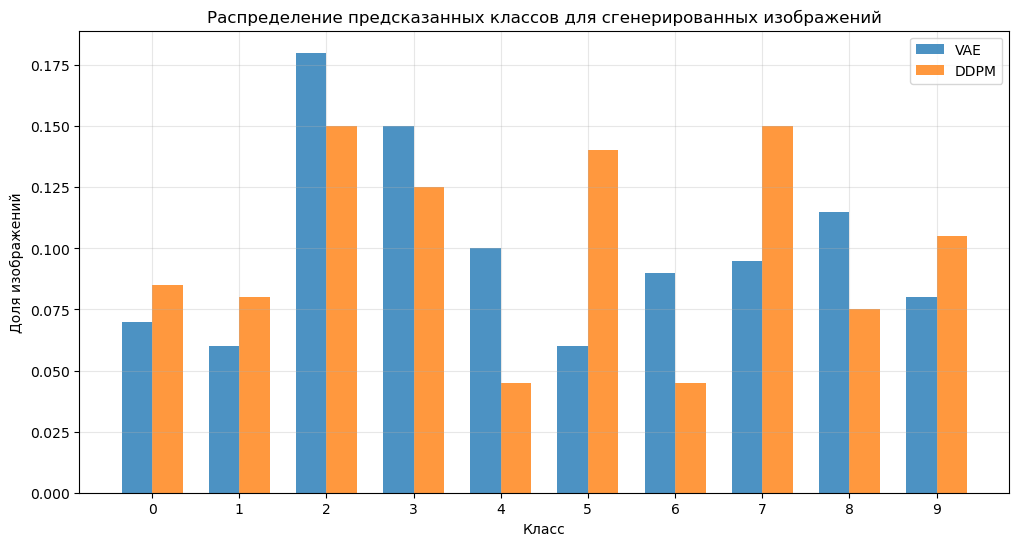

In [14]:
print("Визуальный анализ")

# 1. Сравнение качества для разных классов
def analyze_class_distribution(metrics, title):
    predictions = metrics['predictions']
    unique, counts = np.unique(predictions, return_counts=True)
    return dict(zip(unique, counts / len(predictions)))

vae_class_dist = analyze_class_distribution(vae_metrics, 'VAE')
ddpm_class_dist = analyze_class_distribution(ddpm_metrics, 'DDPM')

plt.figure(figsize=(12, 6))
x = np.arange(10)
width = 0.35

vae_probs = [vae_class_dist.get(i, 0) for i in range(10)]
ddpm_probs = [ddpm_class_dist.get(i, 0) for i in range(10)]

plt.bar(x - width/2, vae_probs, width, label='VAE', alpha=0.8)
plt.bar(x + width/2, ddpm_probs, width, label='DDPM', alpha=0.8)
plt.xlabel('Класс')
plt.ylabel('Доля изображений')
plt.title('Распределение предсказанных классов для сгенерированных изображений')
plt.xticks(x, range(10))
plt.legend()
plt.grid(True, alpha=0.3)
plt.savefig('./images/class_distribution.png', dpi=150, bbox_inches='tight')
plt.show()